<a href="https://colab.research.google.com/github/Saadmoquim/physicscode/blob/main/PHY421_assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

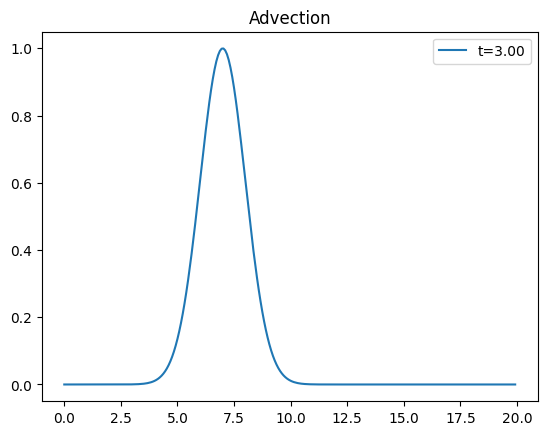

In [1]:
#question 1 part i
import numpy as np
import matplotlib.pyplot as plt


L = 20
N = 256
x = np.linspace(0, L, N, endpoint=False)
dx = L/N

k = 2*np.pi*np.fft.fftfreq(N, d=dx)

sigma = 1.0
x0 = L/2
y = np.exp(-(x-x0)**2/(2*sigma**2))

dt = 0.01
tmax = 3
steps = int(tmax/dt)

for _ in range(steps):
    y_hat = np.fft.fft(y)
    y_hat *= np.exp(1j*k*dt)
    y = np.fft.ifft(y_hat).real

plt.plot(x, y, label="t=%.2f"%tmax)
plt.title("Advection")
plt.legend()
plt.show()

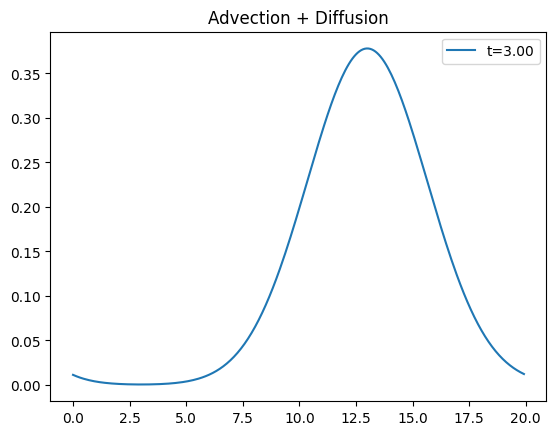

In [2]:
#1 part ii
import numpy as np
import matplotlib.pyplot as plt

L = 20
N = 256
x = np.linspace(0, L, N, endpoint=False)
dx = L/N

k = 2*np.pi*np.fft.fftfreq(N, d=dx)

sigma = 1.0
x0 = L/2
y = np.exp(-(x-x0)**2/(2*sigma**2))

dt = 0.01
tmax = 3
steps = int(tmax/dt)

for _ in range(steps):
    y_hat = np.fft.fft(y)
    y_hat *= np.exp((-1j*k - k**2)*dt)
    y = np.fft.ifft(y_hat).real

plt.plot(x, y, label="t=%.2f"%tmax)
plt.title("Advection + Diffusion")
plt.legend()
plt.show()

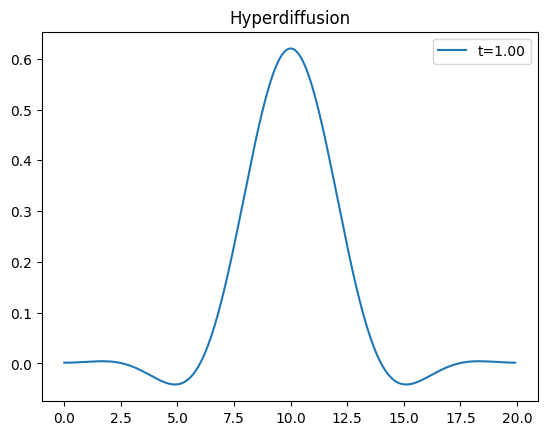

In [3]:
#1 part iii
import numpy as np
import matplotlib.pyplot as plt

L = 20
N = 256
x = np.linspace(0, L, N, endpoint=False)
dx = L/N

k = 2*np.pi*np.fft.fftfreq(N, d=dx)

sigma = 1.0
x0 = L/2
y = np.exp(-(x-x0)**2/(2*sigma**2))

dt = 0.01
tmax = 1
steps = int(tmax/dt)

for _ in range(steps):
    y_hat = np.fft.fft(y)
    y_hat *= np.exp(-(k**4)*dt)
    y = np.fft.ifft(y_hat).real

plt.plot(x, y, label="t=%.2f"%tmax)
plt.title("Hyperdiffusion")
plt.legend()
plt.show()

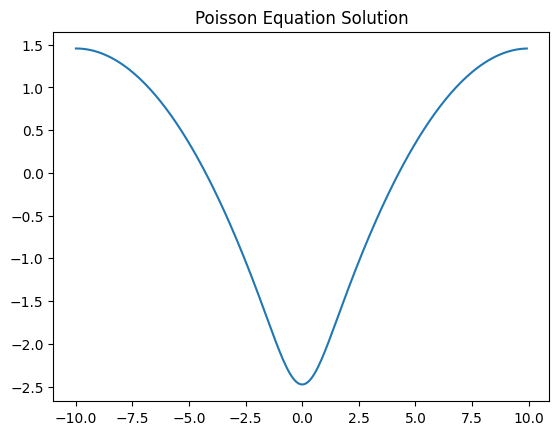

In [4]:
#1 part iv
import numpy as np
import matplotlib.pyplot as plt

L = 20
N = 256
x = np.linspace(-L/2, L/2, N, endpoint=False)
dx = L/N

k = 2*np.pi*np.fft.fftfreq(N, d=dx)

f = np.exp(-x**2)

f_hat = np.fft.fft(f)

y_hat = np.zeros_like(f_hat, dtype=complex)
y_hat[1:] = -f_hat[1:] / (k[1:]**2)
y_hat[0] = 0

y = np.fft.ifft(y_hat).real

plt.plot(x, y)
plt.title("Poisson Equation Solution")
plt.show()

8.28125


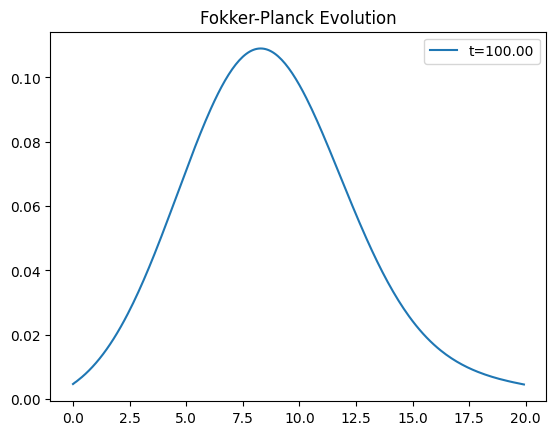

In [10]:
#question 2,fokker planck
import numpy as np
import matplotlib.pyplot as plt

L = 20
N = 256
x = np.linspace(0, L, N, endpoint=False)
dx = L/N

k = 2*np.pi*np.fft.fftfreq(N, d=dx)

D = 0.15
kappa = 0.01

sigma = 1.0
x0 = L/4
rho = np.exp(-(x-x0)**2/(2*sigma**2))
rho /= np.sum(rho)*dx

u_prime = kappa*(x - L/2)

dt = 0.01
tmax = 100
steps = int(tmax/dt)

def compute_rhs(rho):
    rho_hat = np.fft.fft(rho)


    d2rho = np.fft.ifft(-k**2 * rho_hat).real


    product = rho * u_prime
    product_hat = np.fft.fft(product)
    drift = np.fft.ifft(1j * k * product_hat).real

    return D * d2rho + drift

#rk4
for _ in range(steps):
    k1 = compute_rhs(rho)
    k2 = compute_rhs(rho + 0.5*dt*k1)
    k3 = compute_rhs(rho + 0.5*dt*k2)
    k4 = compute_rhs(rho + dt*k3)

    rho += (dt/6)*(k1 + 2*k2 + 2*k3 + k4)

    rho /= np.sum(rho)*dx
print(x[np.argmax(rho)])

plt.plot(x, rho, label="t=%.2f"%tmax)
plt.title("Fokker-Planck Evolution")
plt.legend()
plt.show()

**some remarks**:the potential is too weak and there is barely any drifting for a shorter time scale.

---


I introduced print(x[np.argmax(rho)]) which checks the drift from initial condition.

---


$x_0=L/4$ is 5 units on the length scale and it drifts to 8.28 after $t_{max}=100$

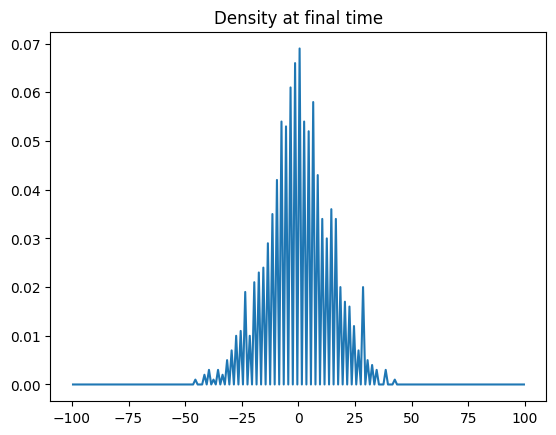

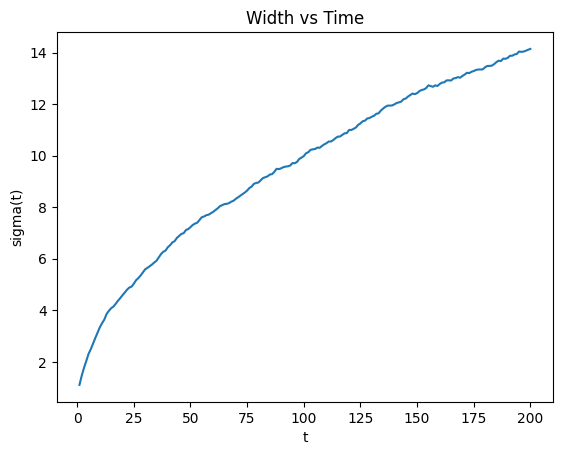

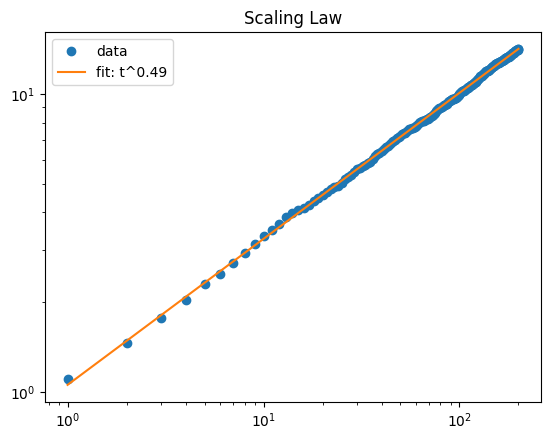

Estimated exponent beta = 0.48996305919569905


In [11]:
#problem 3
import numpy as np
import matplotlib.pyplot as plt

Nwalkers = 1000
tmax = 200

positions = np.zeros(Nwalkers)

sigmas = []
times = []

bins = np.arange(-100, 101)

for t in range(1, tmax+1):


    steps = np.random.choice([-1, 1], size=Nwalkers)
    positions += steps

    hist, edges = np.histogram(positions, bins=bins, density=True)
    x = 0.5*(edges[:-1] + edges[1:])

    sigma = np.sqrt(np.sum(x**2 * hist))

    sigmas.append(sigma)
    times.append(t)

plt.plot(x, hist)
plt.title("Density at final time")
plt.show()

plt.plot(times, sigmas)
plt.xlabel("t")
plt.ylabel("sigma(t)")
plt.title("Width vs Time")
plt.show()

plt.loglog(times, sigmas, 'o', label="data")


coeffs = np.polyfit(np.log(times), np.log(sigmas), 1)
beta = coeffs[0]

plt.loglog(times, np.exp(coeffs[1]) * np.array(times)**beta, label=f"fit: t^{beta:.2f}")
plt.legend()
plt.title("Scaling Law")
plt.show()

print("Estimated exponent beta =", beta)

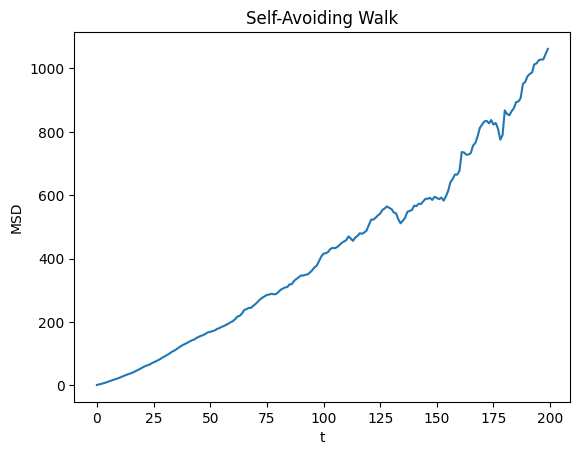

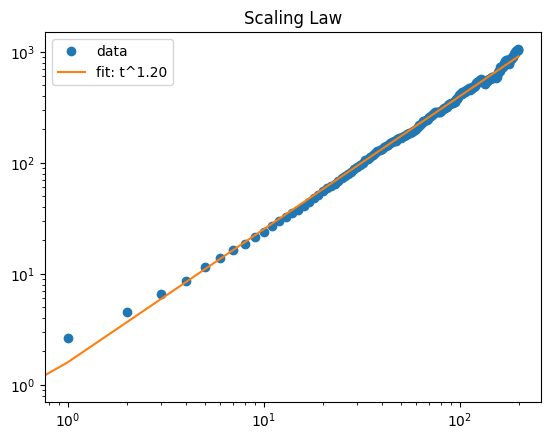

Estimated beta = 1.1989918655161977


In [12]:
#problem 4, self avoiding walker
import numpy as np
import matplotlib.pyplot as plt
import random


n_steps = 200
n_walks = 500


moves = [(1,0), (-1,0), (0,1), (0,-1)]

msd = np.zeros(n_steps)
counts = np.zeros(n_steps)

for _ in range(n_walks):

    visited = set()
    x, y = 0, 0
    visited.add((x,y))

    for t in range(n_steps):

        neighbors = [(x+dx, y+dy) for dx,dy in moves]
        allowed = [p for p in neighbors if p not in visited]

        if not allowed:
            break


        x, y = random.choice(allowed)
        visited.add((x,y))

        r2 = x**2 + y**2

        msd[t] += r2
        counts[t] += 1

valid = counts > 0
msd[valid] /= counts[valid]

t_vals = np.arange(n_steps)[valid]

plt.plot(t_vals, msd[valid])
plt.xlabel("t")
plt.ylabel("MSD")
plt.title("Self-Avoiding Walk")
plt.show()

plt.loglog(t_vals, msd[valid], 'o', label="data")

coeffs = np.polyfit(np.log(t_vals[1:]), np.log(msd[valid][1:]), 1)
beta = coeffs[0]

plt.loglog(t_vals, np.exp(coeffs[1]) * t_vals**beta, label=f"fit: t^{beta:.2f}")
plt.legend()
plt.title("Scaling Law")
plt.show()

print("Estimated beta =", beta)

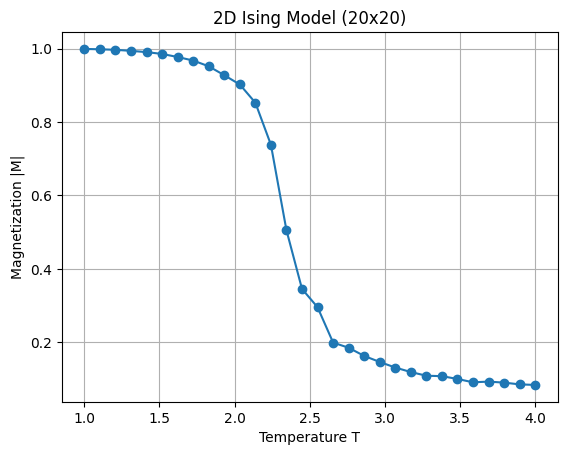

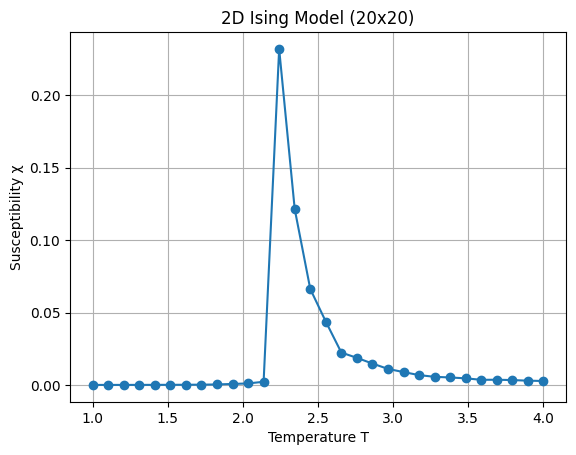

In [14]:
import numpy as np
import matplotlib.pyplot as plt

L = 20
N = L * L
J = 1.0

temps = np.linspace(1.0, 4.0, 30)

eq_sweeps = 2000
meas_sweeps = 5000
skip = 10

def init_lattice():
    return np.random.choice([-1, 1], size=(L, L))

def delta_E(lattice, i, j):
    s = lattice[i, j]
    nn = lattice[(i+1)%L, j] + lattice[(i-1)%L, j] + \
         lattice[i, (j+1)%L] + lattice[i, (j-1)%L]
    return 2 * J * s * nn

def mc_sweep(lattice, T):
    for _ in range(N):
        i, j = np.random.randint(0, L, 2)
        dE = delta_E(lattice, i, j)
        if dE < 0 or np.random.rand() < np.exp(-dE / T):
            lattice[i, j] *= -1


M_vals = []
chi_vals = []

for T in temps:
    lattice = init_lattice()


    for _ in range(eq_sweeps):
        mc_sweep(lattice, T)


    M_list = []

    for step in range(meas_sweeps):
        mc_sweep(lattice, T)

        if step % skip == 0:
            M = np.sum(lattice) / N
            M_list.append(M)

    M_list = np.array(M_list)


    M_vals.append(np.mean(np.abs(M_list)))
    chi_vals.append((np.mean(M_list**2) - np.mean(M_list)**2) / T)


plt.plot(temps, M_vals, 'o-')
plt.xlabel("Temperature T")
plt.ylabel("Magnetization |M|")
plt.title("2D Ising Model (20x20)")
plt.grid()
plt.show()

plt.plot(temps, chi_vals, 'o-')
plt.xlabel("Temperature T")
plt.ylabel("Susceptibility χ")
plt.title("2D Ising Model (20x20)")
plt.grid()
plt.show()